In [1]:
import sys 
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import gc

from modules import get_model
from kvcache_modules import get_kv_model

DEVICE="cuda"

In [2]:
dic_model_colors = {
    "W/o KVCache":  "#573030FF",  # semi-transparent brown
    "W/ KVCache": "#305757FF",  # semi-transparent teal
}

dic_model_symbols = {
    "W/o KVCache":  "x",   # cross
    "W/ KVCache": "o",   # circle
}

labels = {
    "W/o KVCache":  r"W/o KV Cache",
    "W/ KVCache": r"W/ KV Cache",
}

Using CausalRevIN with KV caching for inference.


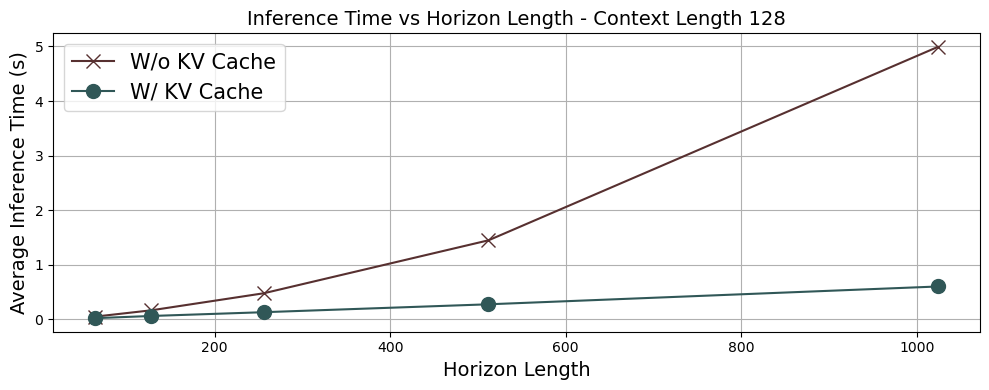

Using CausalRevIN with KV caching for inference.


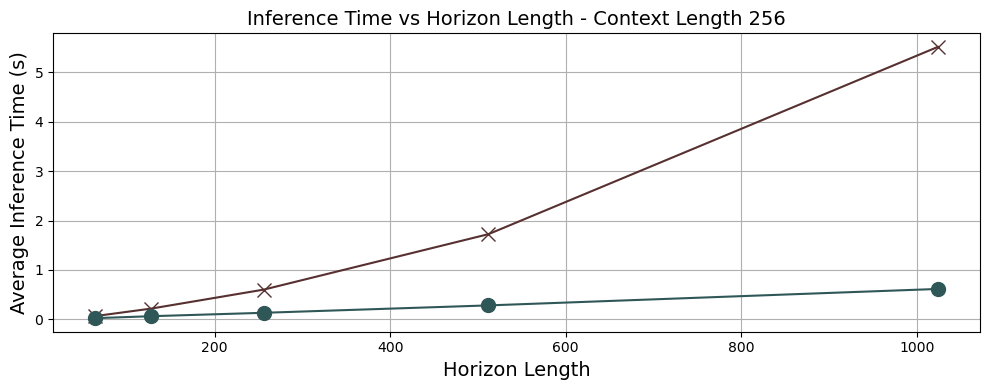

Using CausalRevIN with KV caching for inference.


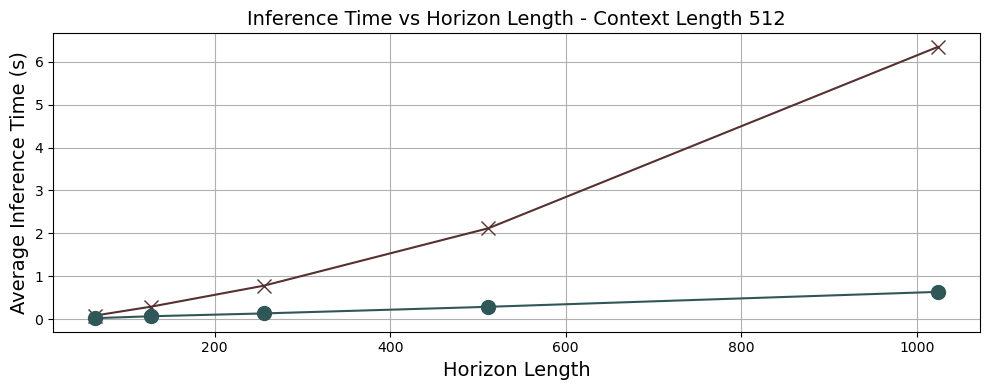

Using CausalRevIN with KV caching for inference.


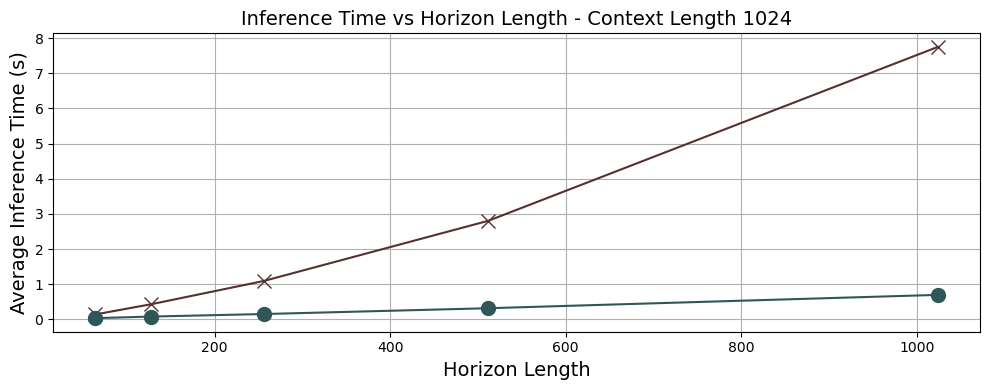

In [7]:
import kvcache_modules
horizons = [64, 128, 256, 512, 1024]
context_lens = [128, 256, 512, 1024]
n_runs = 2
speed = {h: {s:[] for s in labels.keys()} for h in horizons}
with torch.no_grad():
    for context_len in context_lens:
        x = torch.randn(5, context_len).to(DEVICE)
        for rev_strategy in labels.keys():
            if rev_strategy == "W/ KVCache":
                model = get_model(revin_strategy="CausalRevIN", use_asinh=True, device=DEVICE, kv_cache_if_possible=True, seq_len=context_len)
            else:
                model = get_model(revin_strategy="CausalRevIN", use_asinh=True, device=DEVICE, kv_cache_if_possible=False, seq_len=context_len)
            for target_len in horizons:
                # Warmup (VERY IMPORTANT)
                for _ in range(2):
                    model.forecast(x, target_len=target_len)
                for run in range(n_runs):
                    start = torch.cuda.Event(enable_timing=True)
                    end = torch.cuda.Event(enable_timing=True)
                    torch.cuda.empty_cache()
                    torch.cuda.reset_peak_memory_stats()
                    start.record()
                    model.forecast(x, target_len=target_len)
                    end.record()
                    torch.cuda.synchronize()
                    elapsed_time = start.elapsed_time(end) / 1000  # Convert ms → seconds
                    speed[target_len][rev_strategy].append(elapsed_time)
                torch.cuda.empty_cache()
                gc.collect()

        plt.figure(figsize=(10, 4))
        for rev_strategy in labels.keys():
            means = [np.mean(speed[h][rev_strategy]) for h in horizons]
            plt.plot(horizons, means, marker=dic_model_symbols[rev_strategy], color=dic_model_colors[rev_strategy], label=labels[rev_strategy], markersize=10)
        plt.xlabel('Horizon Length', fontsize=14)
        plt.ylabel('Average Inference Time (s)', fontsize=14)
        plt.title(f'Inference Time vs Horizon Length - Context Length {context_len}', fontsize=14)
        if context_len == 128:
            plt.legend(fontsize=15)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'figures/kvcache/inference_time_comparison_{context_len}.pdf', format='pdf', dpi=300)
        plt.show()